In [6]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [7]:


with open("raw_acn_caltech_sessions.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data["_items"])
print("Initial shape:", df.shape)

Initial shape: (14799, 13)


In [9]:
# 3. CLEANING
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Drop rows with nulls in critical columns
df = df.dropna(subset=["connectionTime","disconnectTime","kWhDelivered","stationID"])



# Safe datetime conversion
df["connectionTime"] = pd.to_datetime(df["connectionTime"], errors="coerce")
df["disconnectTime"] = pd.to_datetime(df["disconnectTime"], errors="coerce")

# Drop rows where conversion failed
df = df.dropna(subset=["connectionTime","disconnectTime"])
df = df[["connectionTime", "disconnectTime", "kWhDelivered", "stationID"]]

df["connectionTime"] = pd.to_datetime(df["connectionTime"])
df["disconnectTime"] = pd.to_datetime(df["disconnectTime"])

df = df[df["kWhDelivered"] > 0]
df = df[df["disconnectTime"] > df["connectionTime"]]

print("After cleaning:", df.shape)

Missing values:
 _id                    0
clusterID              0
connectionTime         0
disconnectTime         0
doneChargingTime    1685
kWhDelivered           0
sessionID              0
siteID                 0
spaceID                0
stationID              0
timezone               0
userID              2087
userInputs          2087
dtype: int64
After cleaning: (14799, 4)


In [10]:
print("Final dataset shape:", df.shape)
print("Any null left?", df.isnull().sum().sum())

Final dataset shape: (14799, 4)
Any null left? 0


In [11]:
# 4. HOURLY AGGREGATION

df["hour_timestamp"] = df["connectionTime"].dt.floor("h")

hourly = (
    df.groupby(["stationID", "hour_timestamp"])["kWhDelivered"]
    .sum()
    .reset_index()
)

hourly.rename(columns={"kWhDelivered": "total_kWh"}, inplace=True)

hourly_full = hourly.copy()
hourly_full.sort_values(["stationID", "hour_timestamp"], inplace=True)

print("Hourly dataset shape:", hourly_full.shape)

Hourly dataset shape: (14713, 3)


In [12]:
# 5. FEATURE ENGINEERING

hourly_full["hour"] = hourly_full["hour_timestamp"].dt.hour
hourly_full["dayofweek"] = hourly_full["hour_timestamp"].dt.dayofweek
hourly_full["month"] = hourly_full["hour_timestamp"].dt.month
hourly_full["day"] = hourly_full["hour_timestamp"].dt.day
hourly_full["weekofyear"] = hourly_full["hour_timestamp"].dt.isocalendar().week.astype(int)

# Cyclical encoding
hourly_full["hour_sin"] = np.sin(2*np.pi*hourly_full["hour"]/24)
hourly_full["hour_cos"] = np.cos(2*np.pi*hourly_full["hour"]/24)

hourly_full["dow_sin"] = np.sin(2*np.pi*hourly_full["dayofweek"]/7)
hourly_full["dow_cos"] = np.cos(2*np.pi*hourly_full["dayofweek"]/7)

# Encode station
hourly_full["station_encoded"] = hourly_full["stationID"].astype("category").cat.codes

In [13]:
# 6. OUTLIER HANDLING
Q1 = hourly_full["total_kWh"].quantile(0.25)
Q3 = hourly_full["total_kWh"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 3 * IQR

hourly_full["total_kWh"] = np.where(
    hourly_full["total_kWh"] > upper_limit,
    upper_limit,
    hourly_full["total_kWh"]
)

In [14]:
# 7. CREATE LAG FEATURES (BEFORE SPLIT - NO LEAKAGE)

hourly_full = hourly_full.sort_values(["stationID", "hour_timestamp"])

hourly_full["lag_1"] = hourly_full.groupby("stationID")["total_kWh"].shift(1)
hourly_full["rolling_3h"] = hourly_full.groupby("stationID")["total_kWh"].transform(lambda x: x.rolling(3).mean())
hourly_full["rolling_24h"] = hourly_full.groupby("stationID")["total_kWh"].transform(lambda x: x.rolling(24).mean())

hourly_full.dropna(inplace=True)

In [15]:
# 8. TIME-BASED SPLIT (STRICT CHRONOLOGICAL)

split_index = int(len(hourly_full)*0.8)
split_date = hourly_full["hour_timestamp"].sort_values().iloc[split_index]

train = hourly_full[hourly_full["hour_timestamp"] < split_date].copy()
test  = hourly_full[hourly_full["hour_timestamp"] >= split_date].copy()

print("Train size:", train.shape)
print("Test size:", test.shape)

Train size: (10872, 16)
Test size: (2722, 16)


In [16]:
# 9. DEFINE FEATURES

features = [
    "station_encoded",
    "hour","dayofweek","month","day","weekofyear",
    "hour_sin","hour_cos","dow_sin","dow_cos",
    "lag_1","rolling_3h","rolling_24h"
]

target = "total_kWh"

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]


In [17]:
# 10. MODEL TRAINING

linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

models = {
    "LinearRegression": linear_pipeline,
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(),
    "LightGBM": LGBMRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])

    print(f"\n{name}")
    print("MAE:", round(mae,4))
    print("RMSE:", round(rmse,4))
    print("R2:", round(r2,4))

results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"])
print("\nModel Comparison")
print(results_df)


LinearRegression
MAE: 4.1284
RMSE: 6.0836
R2: 0.6897

RandomForest
MAE: 4.2238
RMSE: 6.3989
R2: 0.6567

GradientBoosting
MAE: 4.2853
RMSE: 6.4584
R2: 0.6503
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000764 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 991
[LightGBM] [Info] Number of data points in the train set: 10872, number of used features: 13
[LightGBM] [Info] Start training from score 8.574886

LightGBM
MAE: 4.4232
RMSE: 6.8204
R2: 0.61

Model Comparison
              Model       MAE      RMSE        R2
0  LinearRegression  4.128441  6.083592  0.689740
1      RandomForest  4.223815  6.398929  0.656743
2  GradientBoosting  4.285295  6.458392  0.650334
3          LightGBM  4.423176  6.820432  0.610032


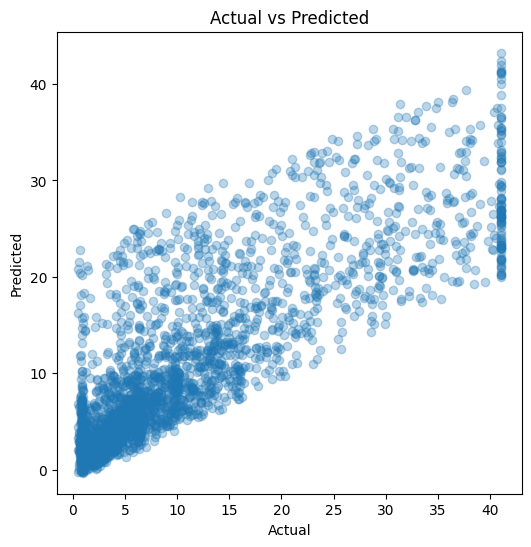

In [18]:
# 11. ACTUAL VS PREDICTED PLOT

best_model_name = results_df.sort_values("RMSE").iloc[0]["Model"]
best_model = models[best_model_name]

preds = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

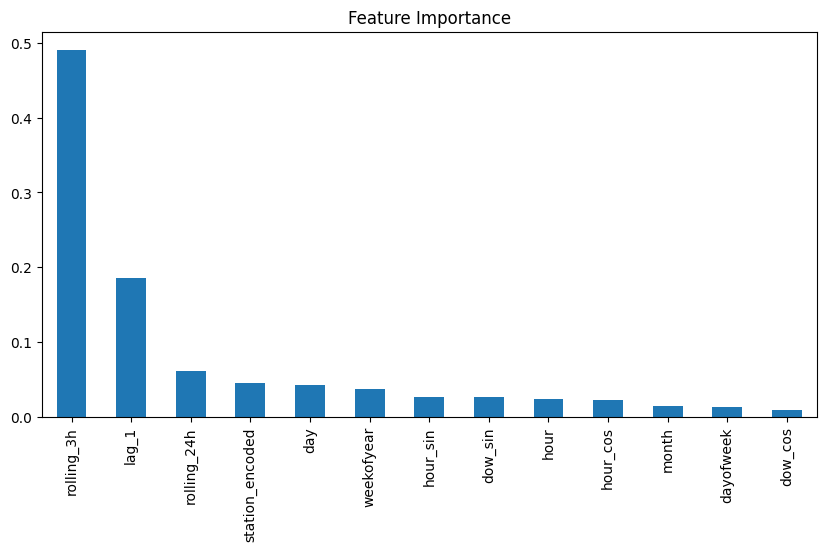

In [19]:
# 12. FEATURE IMPORTANCE

rf_model = models["RandomForest"]
importances = pd.Series(rf_model.feature_importances_, index=features)

importances.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance")
plt.show()

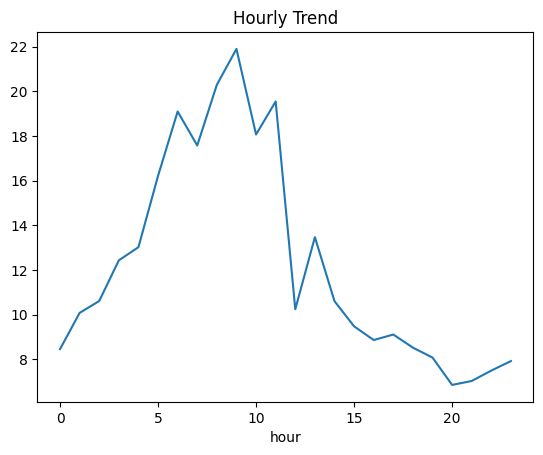

In [20]:
# 13. TREND ANALYSIS
hourly_full.groupby("hour")["total_kWh"].mean().plot(title="Hourly Trend")
plt.show()


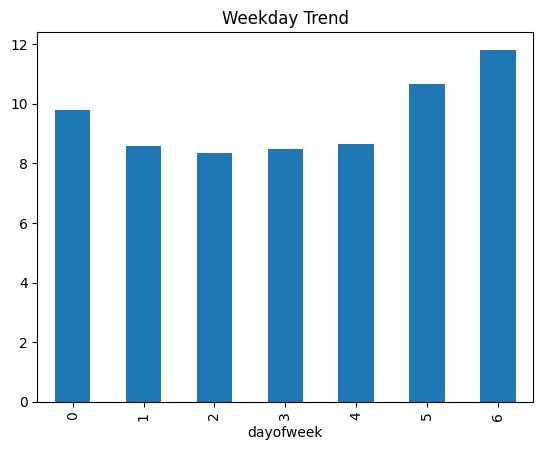

In [21]:
hourly_full.groupby("dayofweek")["total_kWh"].mean().plot(kind="bar", title="Weekday Trend")
plt.show()

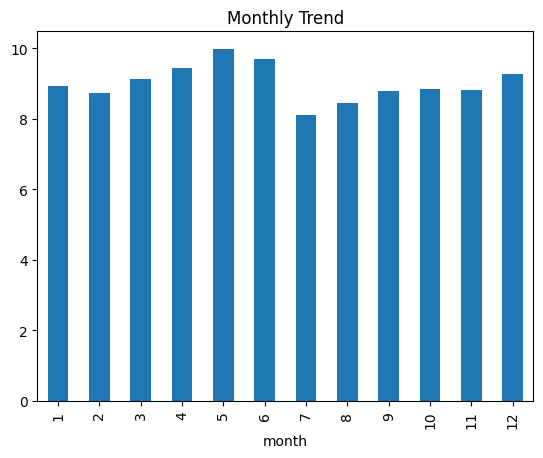

In [22]:
hourly_full.groupby("month")["total_kWh"].mean().plot(kind="bar", title="Monthly Trend")
plt.show()

In [23]:
# 14. SAVE BEST MODEL

joblib.dump(best_model, "best_ev_demand_model.pkl")
print("Best model saved:", best_model_name)

Best model saved: LinearRegression


In [24]:
from google.colab import files
files.download("best_ev_demand_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>